<a href="https://colab.research.google.com/github/cybericdata/real_estate/blob/main/Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import glob
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
path = "./data/*.csv"

csv_files = glob.glob(path)

df_list = []
df_first = pd.read_csv(csv_files[0])
df_list.append(df_first)

# Read the remaining files without headers, using the first file's columns
for file in csv_files[1:]:
    df = pd.read_csv(file, header=None, names=df_first.columns)
    df_list.append(df)

df = pd.concat(df_list, ignore_index=True)
df.head(1)

,Brand New Premium 3 Bedroom in Lekki Phase 1,"₦ 150,000 per day","Lekki, Lekki Phase 1",500,3,Unfurnished,3.1,Brand New Premium 3 bedroom in Lekki phase 1\nAvailable from: today \nFeatures:\nPS5\nSwimming pool\n24/7...,38768242,active
0,New Two Bedroom in Jahi Abuja,"₦ 130,000 per day","Abuja (FCT), Jahi",500,2,Unfurnished,2,Refundable Caution Fee applies,41023971,active


In [ ]:
#Assign a column
df.columns = ['title', 'price', 'location', 'sqm', 'bedrooms', 'furnishing', 'bathrooms', 'description', 'id', 'status']

In [ ]:
df.describe()

,title,price,location,sqm,bedrooms,furnishing,bathrooms,description,id,status
count,23549,23549,23549,23549,23549,23549,23549,23549,23549,23549
unique,12084,1549,565,645,22,4,21,15259,16912,2
top,4bdrm Duplex in Ajah for sale,"₦ 250,000,000","Lagos State, Lekki",500,4,Unfurnished,5,5bedroom fully detached duplex for sale\nameni...,40737449,active
freq,216,465,1430,1584,6995,12459,6583,50,5,23548


In [ ]:
# Initial Dataset Audit
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23549 entries, 0 to 23548
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   title        23549 non-null  object
 1   price        23549 non-null  object
 2   location     23549 non-null  object
 3   sqm          23549 non-null  object
 4   bedrooms     23549 non-null  object
 5   furnishing   23549 non-null  object
 6   bathrooms    23549 non-null  object
 7   description  23549 non-null  object
 8   id           23549 non-null  object
 9   status       23549 non-null  object
dtypes: object(10)
memory usage: 1.8+ MB


In [ ]:
# price parsing
# Remove non-numeric characters
df["price_clean"] = (
    df["price"]
    .astype(str)
    .str.replace(r"[^\d]", "", regex=True)
    .replace("", np.nan)
    .astype(float)
)

In [ ]:
### Handling duplicates
df["id"].duplicated().sum()

df = df.drop_duplicates(
    subset=["title", "location", "price_clean", "bedrooms", "bathrooms"]
)

df = df.drop_duplicates(subset=["description"])

df.count()

title          14480
price          14480
location       14480
sqm            14480
bedrooms       14480
furnishing     14480
bathrooms      14480
description    14480
id             14480
status         14480
price_clean    14479
dtype: int64

In [ ]:
df["furnishing"] = (
    df["furnishing"]
    .str.lower()
    .str.strip()
    .fillna("unknown")
)

df["state"] = df["location"].str.split(",").str[0].str.strip()
df["area"] = df["location"].str.split(",").str[-1].str.strip()

df["bedrooms"] = pd.to_numeric(df["bedrooms"], errors="coerce")
df["bathrooms"] = pd.to_numeric(df["bathrooms"], errors="coerce")


In [ ]:
### Text Processing for the model
import re
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\n", " ", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["title_clean"] = df["title"].apply(clean_text)
df["description_clean"] = df["description"].apply(clean_text)

In [ ]:
df = df.drop(columns=["description"])

### FEATURE ENGINEERING

In [ ]:
df["sqm"] = pd.to_numeric(df["sqm"], errors='coerce')
df["price_per_sqm"] = df["price_clean"] / df["sqm"]
df["price_per_sqm"] = df["price_per_sqm"].round(1)

In [ ]:
df["size_category"] = pd.cut(
    df["sqm"],
    bins=[0, 250, 500, 1000, np.inf],
    labels=["small", "medium", "large", "luxury"]
)

In [ ]:
df["is_luxury"] = (
    (df["bedrooms"].fillna(0) >= 4) &
    (df["bathrooms"].fillna(0) >= 4) &
    (df["price_clean"] > df["price_clean"].quantile(0.75))
).astype(int)


In [ ]:
df.head(2)

,title,price,location,sqm,bedrooms,furnishing,bathrooms,id,status,price_clean,state,area,title_clean,description_clean,price_per_sqm,size_category,is_luxury
0,New Two Bedroom in Jahi Abuja,"₦ 130,000 per day","Abuja (FCT), Jahi",500.0,2.0,unfurnished,2.0,41023971,active,130000.0,Abuja (FCT),Jahi,new two bedroom in jahi abuja,refundable caution fee applies,260.0,medium,0
1,"3 Bedroom Terrace in Naf Valley Estate, Asokor...","₦ 115,000,000","Abuja (FCT), Asokoro",500.0,2.0,unfurnished,2.0,28913134,active,115000000.0,Abuja (FCT),Asokoro,bedroom terrace in naf valley estate asokoro f...,bedroom terrace duplex for sale at naf valley ...,230000.0,medium,0


In [ ]:
numeric_features = [
    "price_clean",
    "bedrooms",
    "bathrooms",
    "sqm",
    "price_per_sqm",
    "is_luxury"
]

corr_df = df[numeric_features]
corr_matrix = corr_df.corr(method="pearson")
corr_matrix

,price_clean,bedrooms,bathrooms,sqm,price_per_sqm,is_luxury
price_clean,1.000000,0.089546,0.087935,0.045924,0.499744,0.212313
bedrooms,0.089546,1.000000,0.888792,0.149280,0.014052,0.323204
bathrooms,0.087935,0.888792,1.000000,0.153265,0.011962,0.313437
sqm,0.045924,0.149280,0.153265,1.000000,-0.054371,0.055882
price_per_sqm,0.499744,0.014052,0.011962,-0.054371,1.000000,0.089364
is_luxury,0.212313,0.323204,0.313437,0.055882,0.089364,1.000000


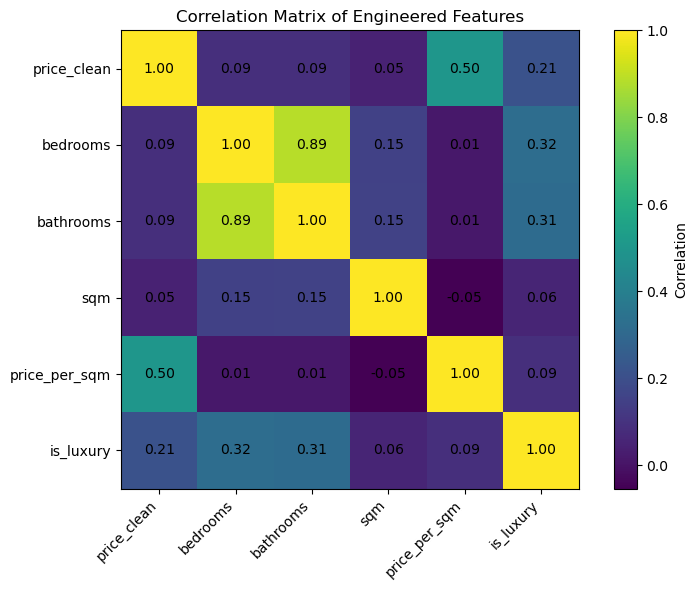

price_clean      1.000000
price_per_sqm    0.499744
is_luxury        0.212313
bedrooms         0.089546
bathrooms        0.087935
sqm              0.045924
Name: price_clean, dtype: float64

In [ ]:
import matplotlib.pyplot as plt

numeric_features = [
    "price_clean",
    "bedrooms",
    "bathrooms",
    "sqm",
    "price_per_sqm",
    "is_luxury"
]

corr = df[numeric_features].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr)
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr)), corr.columns)

# Add numeric correlation values
for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha="center", va="center")

plt.title("Correlation Matrix of Engineered Features")
plt.tight_layout()
plt.show()

price_corr = corr_matrix["price_clean"].sort_values(ascending=False)
price_corr

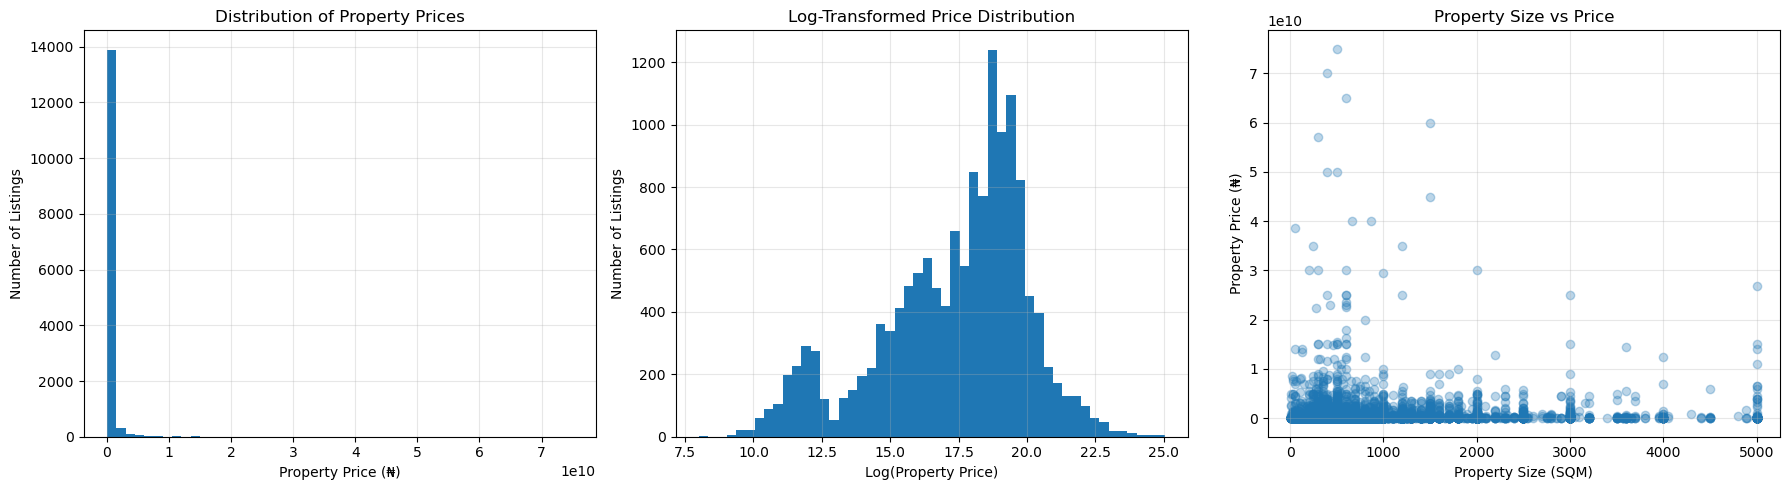

In [ ]:
# Log-transform price
df["log_price"] = np.log1p(df["price_clean"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -------------------------------
# 1. Raw Price Distribution
# -------------------------------
axes[0].hist(df["price_clean"], bins=50)
axes[0].set_title("Distribution of Property Prices")
axes[0].set_xlabel("Property Price (₦)")
axes[0].set_ylabel("Number of Listings")
axes[0].grid(alpha=0.3)

# -------------------------------
# 2. Log-Transformed Price
# -------------------------------
axes[1].hist(df["log_price"], bins=50)
axes[1].set_title("Log-Transformed Price Distribution")
axes[1].set_xlabel("Log(Property Price)")
axes[1].set_ylabel("Number of Listings")
axes[1].grid(alpha=0.3)

# -------------------------------
# 3. Price vs Property Size
# -------------------------------
axes[2].scatter(df["sqm"], df["price_clean"], alpha=0.3)
axes[2].set_title("Property Size vs Price")
axes[2].set_xlabel("Property Size (SQM)")
axes[2].set_ylabel("Property Price (₦)")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### FINAL FEATURE SELECTION FOR ML

In [ ]:
features = [
    "bedrooms",
    "bathrooms",
    "sqm",
    "price_per_sqm",
    "is_luxury",
    "furnishing",
    "state",
    "area"
]

X = df[features]
y = df["price_clean"]


In [ ]:
df["price_clean"].isna().sum()

df_model = df.dropna(subset=["price_clean"]).copy()

In [ ]:
X = df_model[features]
y = df_model["price_clean"]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# y_train.isna().sum()
# y_test.isna().sum()


In [ ]:
num_features = [
    "bedrooms",
    "bathrooms",
    "sqm",
    "price_per_sqm",
    "is_luxury"
]

cat_features = [
    "furnishing",
    "state",
    "area"
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features)
    ]
)


In [ ]:
def evaluate_model(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred))
    }


In [ ]:

lr_model = Pipeline([
    ("prep", preprocessor),
    ("model", LinearRegression())
])



In [ ]:
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_results = evaluate_model(y_test, lr_preds)


In [ ]:
rf_model = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_results = evaluate_model(y_test, rf_preds)



In [ ]:
# Transform data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Train XGBoost directly
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_model.fit(X_train_processed, y_train)
xgb_preds = xgb_model.predict(X_test_processed)
xgb_results = evaluate_model(y_test, xgb_preds)


In [ ]:
ann_model = Pipeline([
    ("prep", preprocessor),
    ("model", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        max_iter=500,
        random_state=42
    ))
])

ann_model.fit(X_train, y_train)
ann_preds = ann_model.predict(X_test)
ann_results = evaluate_model(y_test, ann_preds)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost", "ANN (MLP)"],
    "R2": [lr_results["R2"], rf_results["R2"], xgb_results["R2"], ann_results["R2"]],
    "MAE": [lr_results["MAE"], rf_results["MAE"], xgb_results["MAE"], ann_results["MAE"]],
    "RMSE": [lr_results["RMSE"], rf_results["RMSE"], xgb_results["RMSE"], ann_results["RMSE"]],
})

results_df.sort_values("R2", ascending=False)


,Model,R2,MAE,RMSE
2,XGBoost,0.842314,6.327401e+07,9.823848e+08
1,Random Forest,0.788077,5.577730e+07,1.138869e+09
0,Linear Regression,0.298626,4.083625e+08,2.071856e+09
3,ANN (MLP),-0.005682,3.466499e+08,2.480933e+09


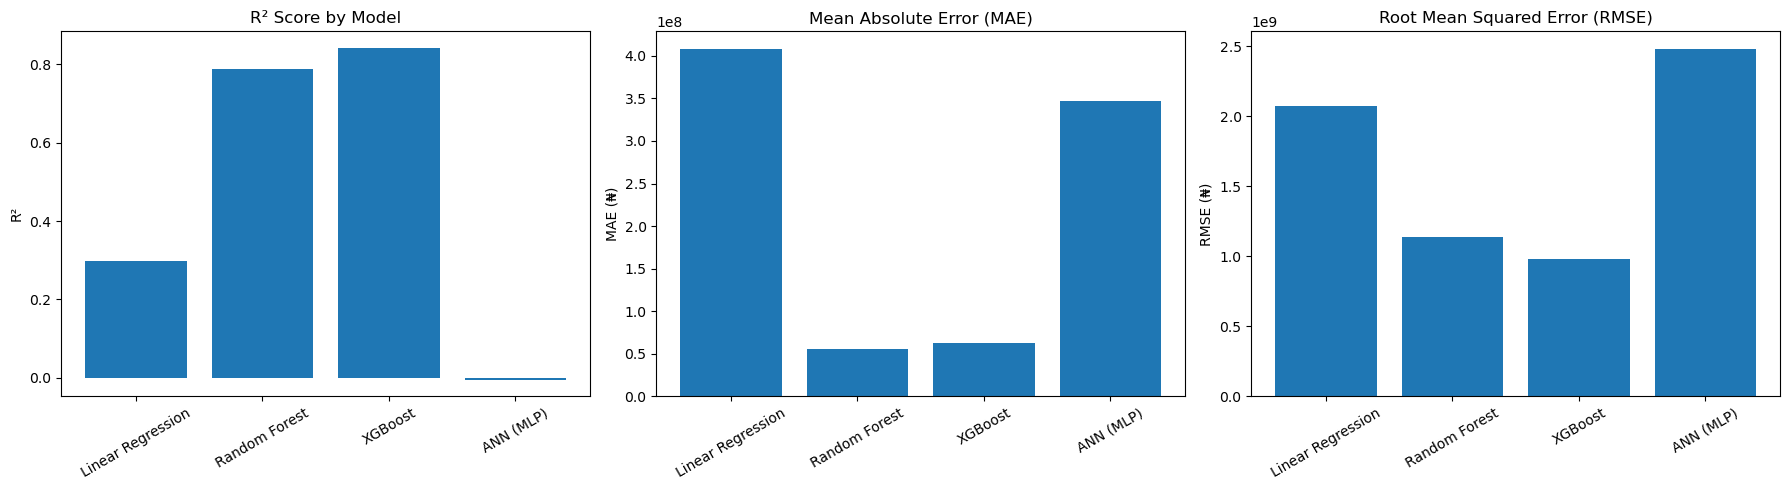

In [ ]:
# Create one-row subplot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R² plot
axes[0].bar(results_df["Model"], results_df["R2"])
axes[0].set_title("R² Score by Model")
axes[0].set_ylabel("R²")
axes[0].tick_params(axis="x", rotation=30)

# MAE plot
axes[1].bar(results_df["Model"], results_df["MAE"])
axes[1].set_title("Mean Absolute Error (MAE)")
axes[1].set_ylabel("MAE (₦)")
axes[1].tick_params(axis="x", rotation=30)

# RMSE plot
axes[2].bar(results_df["Model"], results_df["RMSE"])
axes[2].set_title("Root Mean Squared Error (RMSE)")
axes[2].set_ylabel("RMSE (₦)")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()